# **Identificación de Islas CpG utilizando Modelos Ocultos de Markov (HMM) y el Algoritmo de Viterbi**

## **Presentación del Proyecto**

### **Alumno:**
**Mateo Agustín Rueda**

### **Clave UCC:**
**2210317**

### **Materia:**
**Modelados De Sistemas Biológicos**

---


# Descripcion del problema

## Contexto del problema

Las islas CpG son regiones del ADN donde la frecuencia de citosinas (**C**) y guaninas (**G**) es significativamente mayor que en el resto del genoma. Estas regiones suelen encontrarse cerca de los promotores génicos y juegan un rol clave en la regulación de la expresión génica, ya que suelen estar menos metiladas que otras zonas del ADN.

En el resto del genoma, el dinucleótido **CG** es poco frecuente debido a procesos de metilación y mutación, pero en las islas CpG esta tendencia se invierte y los pares **CG** aparecen de forma sostenida a lo largo de una región continua.

---

## Idea inicial (enfoque ingenuo)

Una primera idea intuitiva es contar directamente la cantidad de pares **"CG"** en una secuencia de ADN. Bajo este enfoque, si una región contiene muchos "CG", se podría decidir que se trata de una isla CpG, y si contiene pocos, que no lo es.

Sin embargo, este enfoque es **limitado** por varias razones:

- No tiene en cuenta la continuidad de las regiones (no modela “bloques” de islas).
- No permite modelar la probabilidad de **entrar o salir** de una isla CpG.
- No captura la estructura estadística global de la secuencia.

Por estas razones, contar pares "CG" de manera directa no refleja adecuadamente la dinámica real del problema.

---

## Enfoque correcto: Cadenas Ocultas de Markov (HMM)

Para modelar correctamente el problema, se utiliza un **Hidden Markov Model (HMM)**, que asume que:

- Existe un **estado interno oculto** que no se observa directamente.
- Las observaciones dependen únicamente de ese estado oculto.
- El sistema evoluciona de manera secuencial.

En este caso, el ADN observado (secuencia de nucleótidos) es el resultado de un proceso oculto que alterna entre dos tipos de regiones.

---

## Definición de los estados

### Estados ocultos (no observables)

Estos representan el tipo de región en el que estamos:

- `I` → Región perteneciente a una **Isla CpG**
- `N` → Región que **No** es una isla CpG

Estos estados son *ocultos* porque no se observan directamente al mirar la secuencia.

### Estados observables

Son los símbolos que sí se observan en la secuencia:

- `A`, `C`, `G`, `T`

Estos corresponden a los nucleótidos reales del ADN.

---



## Matriz de transición (estados ocultos)

La matriz de transición \(A\) describe la probabilidad de pasar de un estado oculto a otro:

\[
A =
\begin{bmatrix}
P(I \rightarrow I) & P(I \rightarrow N) \\
P(N \rightarrow I) & P(N \rightarrow N)
\end{bmatrix}
=
\begin{bmatrix}
0.9 & 0.1 \\
0.1 & 0.9
\end{bmatrix}
\]

Donde:

- \(P(I → I) = 0.9\)
- \(P(I → N) = 0.1\)
- \(P(N → I) = 0.1\)
- \(P(N → N) = 0.9\)

---

## Matriz de emisión (estados observables)

La matriz de emisión \(B\) describe la probabilidad de observar un nucleótido dado el estado oculto:

\[
B =
\begin{bmatrix}
P(A|I) & P(A|N) \\
P(C|I) & P(C|N) \\
P(G|I) & P(G|N) \\
P(T|I) & P(T|N)
\end{bmatrix}
=
\begin{bmatrix}
0.2 & 0.3 \\
0.3 & 0.2 \\
0.3 & 0.2 \\
0.2 & 0.3
\end{bmatrix}
\]

---

## Resumen de los estados

**Estados ocultos (no observables):**
\[
S = \{I, N\}
\]

**Estados observables:**
\[
O = \{A, C, G, T\}
\]

---




Interpretación:

- En las islas CpG (`I`) es más probable observar `C` y `G`.
- Fuera de las islas (`N`) son más comunes `A` y `T`.

Esto captura el comportamiento biológico esperado.

---

## Idea central del modelo

En lugar de contar directamente los pares "CG", el modelo HMM permite:

- Detectar regiones **continuas** ricas en CpG.
- Modelar transiciones entre regiones.
- Inferir los estados ocultos (Isla / No Isla) a partir de la secuencia observada.

De esta forma, el problema se transforma en una tarea de **inferencia de estados ocultos** a partir de una secuencia observable, que es precisamente el objetivo de los modelos ocultos de Markov.



---
---



# **1. Implemente un código (ver recomendaciones abajo) que obtenga la cadena oculta a partir de la cadena de observables, utilizando el algoritmo de Viterbi. Compruebe su correcto funcionamiento con la secuencia ejemplo ACGTCCGCGTGCACGT.**



---
---

### Descripcion

Al igual que en el ejemplo visto en clase, donde se utilizó un modelo de Cadenas Ocultas de Markov (HMM) para inferir el estado del clima (soleado o lluvioso) a partir del estado de ánimo observado (feliz o triste), en este trabajo se aplica el mismo enfoque conceptual a un problema biológico real: la identificación de islas CpG en secuencias de ADN.

En el caso del clima, los estados ocultos no eran directamente observables (el clima real), y solamente se contaba con evidencia indirecta (el estado de ánimo). De forma análoga, en el problema de las islas CpG, los estados ocultos corresponden a si una posición de la secuencia pertenece o no a una isla CpG, mientras que las observaciones disponibles son los nucleótidos de la secuencia (A, C, G y T).

Para resolver este problema se utiliza el algoritmo de **Viterbi**, cuyo objetivo es encontrar la secuencia de estados ocultos más probable dado un conjunto de observaciones.


In [ ]:
import numpy as np

# ================================
# Definición del modelo HMM
# ================================

# Estados ocultos
states = ["I", "N"]  # I = Isla CpG, N = No isla CpG
state_to_idx = {"I": 0, "N": 1}

# Símbolos observables
symbols = ["A", "C", "G", "T"]
sym_to_idx = {"A": 0, "C": 1, "G": 2, "T": 3}

# Matriz de transición A (2x2)
A = np.array([[0.9, 0.1], [0.1, 0.9]])  # desde I  # desde N

# Matriz de emisión B (4x2)
# Filas: A, C, G, T
# Columnas: I, N
B = np.array([[0.2, 0.3], [0.3, 0.2], [0.3, 0.2], [0.2, 0.3]])  # A  # C  # G  # T


def estacionaria(A):
    # A priori asumi que la probabilidad de que sea isla o no isla al comienzo
    #sean equiprobable.
    # Pero Luego vi que en el problema resuelto en clases no se asumia eso,
    #en el caso de soleado y lluvioso.
    # Por lo que cree esta funcion para resolverlo con la la distribución
    #estacionaria π* de una
    # cadena de Markov a partir de la matriz de transición A.

    # Autovalores y autovectores de A^T
    vals, vecs = np.linalg.eig(A.T)

    # Buscar el autovalor más cercano a 1
    idx = np.argmin(np.abs(vals - 1))

    # Obtener el autovector asociado
    v = np.real(vecs[:, idx])

    # Normalizar para que sume 1
    pi = v / np.sum(v)

    # Asegurar que sea positivo
    pi = np.maximum(pi, 0)
    pi = pi / np.sum(pi)

    return pi

In [ ]:
def viterbi(obs_seq, A, B):
    """
    Implementación del algoritmo de Viterbi.

    Parámetros
    ----------
    obs_seq : str
        Secuencia de observaciones (ej. 'ACGT...')
    A : np.ndarray
        Matriz de transición (NxN)
    B : np.ndarray
        Matriz de emisión (MxN)

    Retorna
    -------
    path : list
        Secuencia más probable de estados ocultos
    """

    pi = estacionaria(A)

    """ Probabilidades iniciales (N,) """

    n_states = A.shape[0]
    T = len(obs_seq)

    # Convertir observaciones en índices
    obs_idx = [sym_to_idx[s] for s in obs_seq]

    # Matrices de trabajo
    delta = np.zeros((n_states, T))
    psi = np.zeros((n_states, T), dtype=int)

    # --- Inicialización ---
    for i in range(n_states):
        delta[i, 0] = pi[i] * B[obs_idx[0], i]
        psi[i, 0] = 0

    # --- Recursión ---
    for t in range(1, T):
        for j in range(n_states):

            # En este paso nos ubicamos en el tiempo t.
            # Para cada estado, evaluamos todas las posibles transiciones desde
            # el tiempo anterior (t-1),
            # multiplicando las probabilidades máximas acumuladas por la matriz
            # de transición A.

            # Esto es válido porque la probabilidad de emisión (el nucleotido
            # en esa posicion de la secuencia) se agrega después y es común
            # para todas las transiciones que llegan al mismo estado
            #(En clase vimos que esto se puede hacer ya que se cancelan los
            #terminos en común)

            probs = delta[:, t - 1] * A[:, j]
            psi[j, t] = np.argmax(
                probs
            ) #Aqui se guarda el indice de donde probiene la probabilidad
            #maxima que se guardara en la matriz delta. Este indice nos
            #sirve manternelo guardado ya que
            #Nos permitira hacer el backtracking y poder obtener el camino
            #optimo mas probable.

            delta[j, t] = (
                np.max(probs) * B[obs_idx[t], j]
            )  # Aqui en cambio guardo las probabilidades ya multiplicadas
            # por respectiva posicion de la matriz de emision (B), de forma
            # mas sencilla se multiplica por la probabilidad ser respectivo
            # nucleotido dado el respectivo estado oculto.
            # Que en este caso es el respectivo nucleotido (posicion indexada
            #anteriormente), en la columna j (respectivo estado).


    # --- Retrotrazado ---
    path_idx = np.zeros(T, dtype=int)
    path_idx[-1] = np.argmax(delta[:, -1])

    for t in range(T - 2, -1, -1):
        path_idx[t] = psi[path_idx[t + 1], t + 1]

    # Convertir índices a nombres de estados
    inv_states = {0: "I", 1: "N"}
    path = [inv_states[i] for i in path_idx]

    return path, delta, pi

In [ ]:
# Secuencia de prueba
seq = "ACGTCCGCGTGCACGT"

# Ejecutar Viterbi
path, delta, pi = viterbi(seq, A, B)

# Resultados
print("Secuencia observada:")
print(seq)

print("\nSecuencia de estados ocultos predicha:")
print("".join(path))



Secuencia observada:
ACGTCCGCGTGCACGT

Secuencia de estados ocultos predicha:
IIIIIIIIIIIIIIII


---
---


# **2. Implemente una visualización de tipo mapa de calor (como las mostradas en clase) de las probabilidades de los estados vt(x), donde t es la posición en la secuencia y x representa el estado oculto).**


## Visualización del algoritmo de Viterbi mediante mapas de calor

Para analizar el comportamiento del algoritmo de Viterbi, se construyeron mapas de calor (heatmaps) a partir de la matriz `delta`, que contiene las probabilidades más altas de alcanzar cada estado oculto en cada posición de la secuencia.

En una primera etapa, se utilizó directamente la matriz `delta` para visualizar las **diferencias locales** entre estados. Este mapa de calor permitió observar, para cada posición de la secuencia, qué estado (Isla CpG o No-Isla CpG) era más probable de forma **local**, es decir, considerando únicamente la mejor ruta acumulada hasta ese punto. De esta manera, los colores más intensos representaron las probabilidades relativas más altas, facilitando la identificación visual de cambios de estado a lo largo de la secuencia.

Posteriormente, se generó un segundo mapa de calor incorporando el **camino óptimo global** obtenido mediante el proceso de retrotrazado (backtracking) del algoritmo de Viterbi. A diferencia del primer caso, este mapa no solo reflejó las probabilidades locales, sino que también mostró la secuencia completa de estados más probable a lo largo de toda la cadena de observaciones.

Este enfoque permitió diferenciar claramente entre:

- La dinámica local de las probabilidades (dominada por `delta`)
- La dinámica global del modelo (determinada por el camino más probable reconstruido)

El uso de ambos mapas resulta útil para interpretar el modelo, ya que el primer heatmap permite detectar regiones ambiguas o transiciones débiles, mientras que el segundo muestra la segmentación final más consistente del sistema. En el contexto biológico, esto ayudó a distinguir regiones con comportamiento tipo “Isla CpG” frente a regiones fuera de isla, visualizando tanto la incertidumbre local como la decisión global del modelo.

Estas visualizaciones funcionan como una herramienta diagnóstica para comprender cómo y por qué el algoritmo asigna ciertos estados a cada posición de la secuencia.


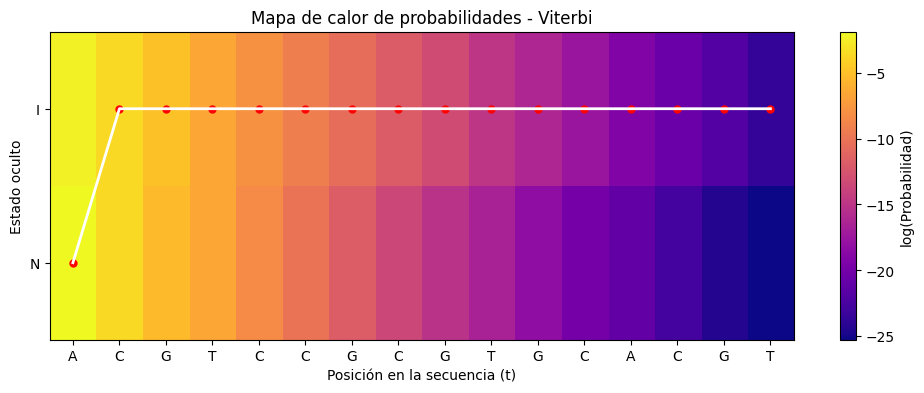

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Heatmap usando log(delta)
# =========================
delta_log = np.log(delta + 1e-12)  # Evita log(0)

plt.figure(figsize=(12, 4))
plt.imshow(delta_log, aspect="auto", cmap="plasma")  # mejor contraste

# Etiquetas
plt.yticks(range(len(states)), states)
plt.xticks(range(len(seq)), list(seq))

plt.colorbar(label="log(Probabilidad)")
plt.xlabel("Posición en la secuencia (t)")
plt.ylabel("Estado oculto")
plt.title("Mapa de calor de probabilidades - Viterbi")

# =========================
# Marcar máximos por tiempo
# =========================
max_idx = np.argmax(delta_log, axis=0)
t = np.arange(len(max_idx))

# Línea y puntos para el camino más probable
plt.plot(t, max_idx, color="white", linewidth=2)
plt.scatter(t, max_idx, color="red", s=25)

plt.show()

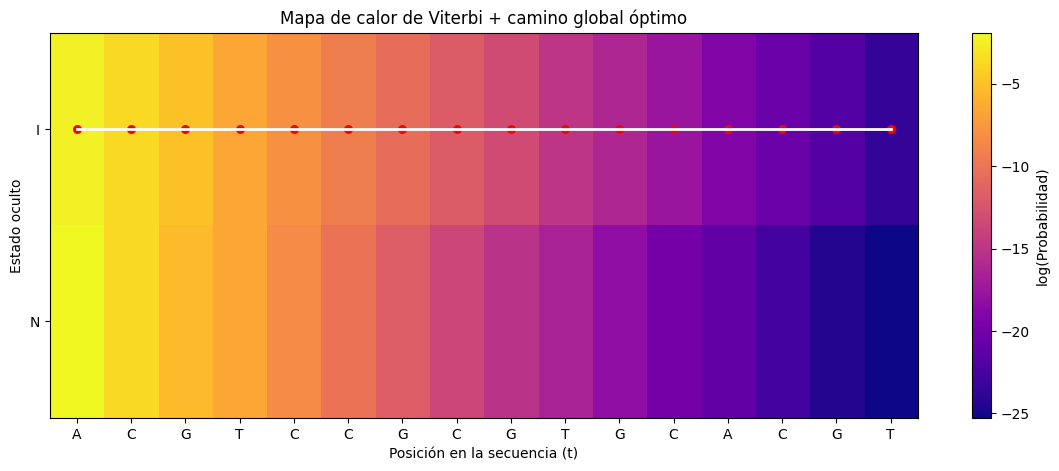

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Heatmap en escala log
# =========================
delta_log = np.log(delta + 1e-12)

plt.figure(figsize=(14, 5))
plt.imshow(delta_log, aspect="auto", cmap="plasma")

# Etiquetas de ejes
states = ["I", "N"]
plt.yticks(range(len(states)), states)
plt.xticks(range(len(seq)), list(seq))

plt.colorbar(label="log(Probabilidad)")
plt.xlabel("Posición en la secuencia (t)")
plt.ylabel("Estado oculto")
plt.title("Mapa de calor de Viterbi + camino global óptimo")

# =========================
# Dibujar el camino global
# =========================

# Convertir camino ("I","N") a índices (0,1)
state_to_idx = {"I": 0, "N": 1}
path_idx = np.array([state_to_idx[s] for s in path])

t = np.arange(len(path_idx))

# Dibujar línea del camino óptimo
plt.plot(t, path_idx, color="white", linewidth=2)

# Dibujar puntos del camino
plt.scatter(t, path_idx, color="red", s=30)

plt.show()

---
---


# **3. Utilice el código para analizar distintas secuencias de su elección. El requisito es ver la transición entre regiones I y N y comentar al respecto. Discuta estas transiciones para las distintas secuencias, sirviéndose de los valores de las probabilidades y de los gráficos generados por el código del inciso anterior.**

### **Análisis de las secuencias de prueba**

Para evaluar el comportamiento del modelo HMM y del algoritmo de Viterbi, se analizaron secuencias sintéticas diseñadas para representar distintos escenarios biológicos: regiones puras de islas CpG, regiones no CpG, mezclas débiles y transiciones entre estados.

En el caso **“I puro”** (`CGCGCGCGCGCGCG`), el algoritmo clasificó toda la secuencia como **Isla CpG (I)**. Esto se debe a que las bases `C` y `G` tienen una mayor probabilidad de emisión en el estado I que en el estado N, haciendo que el camino más probable favorezca consistentemente el estado de isla.

En la secuencia **“N puro”** (`ATATATATATATAT`), el modelo asignó todos los estados como **No isla (N)**. Aquí ocurre lo inverso: las bases `A` y `T` son más probables bajo el estado N, y no existe ninguna evidencia para justificar un cambio de estado.

Para la secuencia **“Mezcla débil”** (`CGATCGATCGATCG`), el resultado fue una clasificación completa como estado **I**. Esto muestra que el modelo no responde únicamente a proporciones globales de nucleótidos, sino que también considera la dinámica de permanencia en un estado (matriz de transición). Aun cuando aparecen `A` y `T`, estas no forman bloques suficientemente largos como para compensar el alto costo de transición entre estados.

En la secuencia **“I → N”** (`CGCGCGCGAAAAAA`), se observa una transición clara desde **I** hacia **N**. La primera mitad rica en `C` y `G` favorece el estado de isla, mientras que el bloque consecutivo de `A` fuerza una transición hacia el estado No isla. Este cambio ocurre cuando la evidencia local a favor de N supera el costo de transición.

En el caso **“N → I”** (`ATATATATGGGGGG`), sucede el comportamiento inverso: una región inicial dominada por `A/T` mantiene al sistema en el estado **N**, pero un bloque consecutivo de `G` induce el cambio hacia el estado **I**, resultando en una transición estable hacia una región tipo CpG.

Finalmente, en la secuencia **“Subumbral”** (`CGCGCGAAAAAAAAAAACGCGCG`), el modelo muestra una transición temporal: comienza en **I**, pasa a una región extendida de **N** debido al bloque largo de `A`, y luego vuelve a **I** cuando reaparecen bases ricas en `C` y `G`. Este caso evidencia cómo el modelo detecta cambios locales sostenidos en la composición de la secuencia y no meras fluctuaciones aisladas.

### **Análisis general del comportamiento del modelo**

A partir de las simulaciones realizadas con distintas secuencias, se observó que el modelo HMM junto con el algoritmo de Viterbi no se basa únicamente en el porcentaje global de nucleótidos, sino fundamentalmente en la **estructura local de la secuencia** y en la **persistencia de los estados**.

En primer lugar, el sistema tiende a permanecer completamente en el estado **Isla CpG (I)** cuando la proporción efectiva de nucleótidos `C/G` es mayor al 50% de forma sostenida, o cuando no aparecen bloques consecutivos suficientemente largos de `A/T`. En otras palabras, mientras no exista una “evidencia local fuerte” en contra, el modelo prefiere permanecer en el estado I debido al alto costo probabilístico de cambiar de estado.

Por el contrario, el sistema permanece completamente en el estado **No isla (N)** cuando predominan los nucleótidos `A/T` o cuando los `C/G` aparecen de forma dispersa, sin formar bloques consecutivos suficientemente largos como para justificar una transición.

Un resultado clave del análisis es que las **transiciones entre estados no dependen tanto del porcentaje global de bases**, sino de la aparición de **bloques locales sostenidos**. Específicamente, se observó que una transición de **I → N** ocurre cuando aparece un bloque aproximado de **11 o más nucleótidos consecutivos tipo `A/T`**. Este patrón local genera suficiente evidencia para que el algoritmo supere el “costo” impuesto por las probabilidades de transición y cambie de estado.

De manera análoga, una transición de **N → I** se produce cuando aparece un bloque consecutivo suficientemente largo de `C` y/o `G`. Esto evidencia que el modelo detecta **regiones estructurales locales**, más que simplemente contar frecuencias globales en toda la secuencia.

En síntesis, el modelo se comporta de forma consistente con el concepto biológico de las islas CpG: identifica regiones compactas y sostenidas ricas en `C/G`, y solo cambia de estado cuando existe una evidencia local fuerte y continua que justifique dicha transición.


In [ ]:
secuencias = {
    "I puro": "CGCGCGCGCGCGCG",
    "N puro": "ATATATATATATAT",
    "Mezcla débil": "CGATCGATCGATCG",
    "I → N": "CGCGCGCGAAAAAA",
    "N → I": "ATATATATGGGGGG",
    "Subumbral1": "CGCGCGAAAAAAAAAAACGCGCG",
}

for name, seq in secuencias.items():
    path, delta, pi = viterbi(seq, A, B)
    print(f"\n{name}")
    print("Secuencia:", seq)
    print("Estados:  ", "".join(path))


I puro
Secuencia: CGCGCGCGCGCGCG
Estados:   IIIIIIIIIIIIII

N puro
Secuencia: ATATATATATATAT
Estados:   NNNNNNNNNNNNNN

Mezcla débil
Secuencia: CGATCGATCGATCG
Estados:   IIIIIIIIIIIIII

I → N
Secuencia: CGCGCGCGAAAAAA
Estados:   IIIIIIIINNNNNN

N → I
Secuencia: ATATATATGGGGGG
Estados:   NNNNNNNNIIIIII

Subumbral1
Secuencia: CGCGCGAAAAAAAAAAACGCGCG
Estados:   IIIIIINNNNNNNNNNNIIIIII


## Análisis del caso subumbral con heatmaps  
**Secuencia analizada:** `CGCGCGAAAAAAAAAAACGCGCG`  
**Contexto:** Esta secuencia contiene dos bloques CpG breves separados por una región central muy rica en adeninas (A). Esta zona de A actúa como un “valle” de probabilidad para el estado I, y por lo tanto es la región clave donde el algoritmo de Viterbi debe decidir si abandonar temporalmente el estado CpG.

---


## **Imagen 1 – Heatmap del análisis local (Δ local)**


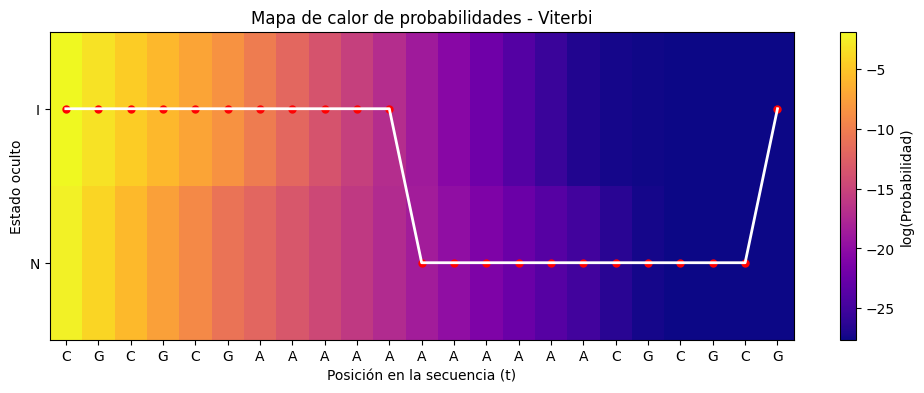


En el heatmap local se visualizan las diferencias de log-probabilidad entre los dos estados posibles (I y N) a medida que avanza la secuencia.  

Al observar esta matriz local se aprecia que:

- Existe una **transicion incorrecta entre I y N** luego de que habia una gran cantidad de adenina.  
- La transición es **tardia**, ya que el cálculo local solo compara, posición por posición, cuál estado parece más favorable sin considerar todavía la trayectoria global.  
- Este comportamiento evidencia que el análisis puramente local **no es suficiente para tomar decisiones consistentes**, ya que los valores aislados pueden influir engañosamente si se los observa de forma independiente.

---

## **Imagen 2 – Heatmap del análisis global (Ψ global / retropropagación de Viterbi)**


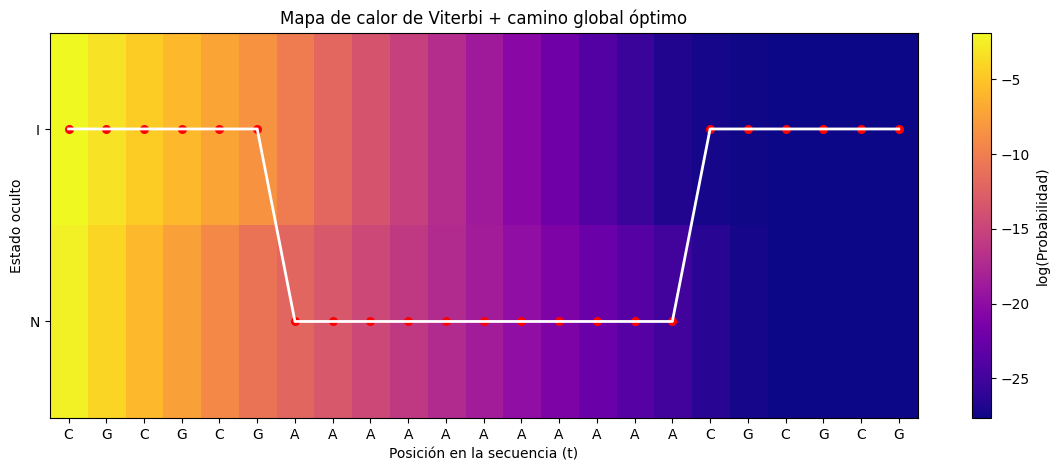


Cuando observamos el heatmap global —la matriz Ψ que utiliza el algoritmo de Viterbi para reconstruir la trayectoria óptima— la interpretación cambia completamente.

El mapa global revela que:

- La matriz Ψ **detecta claramente la presencia de un bloque continuo de adeninas**, y lo hace no por fluctuaciones locales, sino por evaluar **toda la trayectoria acumulada**.
- A diferencia del heatmap local, aquí se observa una **banda coherente y estable** que marca a toda la región central como favorecida para el estado **N**, sin interrupciones espurias.
- La retropropagación del algoritmo de Viterbi elimina los picos locales inconsistentes que aparecían en Δ y **consolida la decisión óptima** basándose en la probabilidad total del camino.
- Al reconstruir la secuencia de estados, Viterbi identifica correctamente una transición:
  - **I → N** al comenzar el bloque de adeninas.
  - **N → I** al finalizarlo, cuando regresan los CpG organizados.

Es decir, mientras el heatmap local muestra un “panorama turbulento”, el heatmap global muestra una **trayectoria ordenada**, reforzando la idea de que una acumulación sostenida de A’s —aunque se encuentre en una región relativamente corta— **es suficiente para forzar la permanencia en N durante toda esa ventana**.

---
---


# **4. Experimentar variando los parámetros del modelo para ver cuán sensible es respecto a estos. Comentelos cambios observados; puede valerse de la comparación de los resultados de secuencias analizadas previamente.**

In [ ]:
# =========================
# Configuraciones de parámetros
# =========================
configuraciones = [
    {
        "nombre": "Modelo base",
        "A": np.array([[0.9, 0.1], [0.1, 0.9]]),
        "B": np.array([[0.2, 0.3], [0.3, 0.2], [0.3, 0.2], [0.2, 0.3]]),
    },
    {
        "nombre": "Muy conservador",
        "A": np.array([[0.97, 0.03], [0.03, 0.97]]),
        "B": np.array([[0.2, 0.3], [0.3, 0.2], [0.3, 0.2], [0.2, 0.3]]),
    },
    {
        "nombre": "Muy sensible",
        "A": np.array([[0.7, 0.3],[0.3, 0.7]]),
        "B": np.array([[0.15, 0.35],[0.35, 0.15],[0.35, 0.15], [0.15, 0.35]]),
},
]

# Distribución inicial
pi = np.array([0.5, 0.5])

# =========================
# Simulaciones
# =========================
for cfg in configuraciones:
    print("\n===============================")
    print(f"Modelo: {cfg['nombre']}")
    print("===============================")

    A = cfg["A"]
    B = cfg["B"]

    for name, seq in secuencias.items():
        path, delta, pi = viterbi(seq, A, B)
        print(f"\n{name}")
        print("Secuencia:", seq)
        print("Estados:  ", "".join(path))


Modelo: Modelo base

I puro
Secuencia: CGCGCGCGCGCGCG
Estados:   IIIIIIIIIIIIII

N puro
Secuencia: ATATATATATATAT
Estados:   NNNNNNNNNNNNNN

Mezcla débil
Secuencia: CGATCGATCGATCG
Estados:   IIIIIIIIIIIIII

I → N
Secuencia: CGCGCGCGAAAAAA
Estados:   IIIIIIIINNNNNN

N → I
Secuencia: ATATATATGGGGGG
Estados:   NNNNNNNNIIIIII

Subumbral1
Secuencia: CGCGCGAAAAAAAAAAACGCGCG
Estados:   IIIIIINNNNNNNNNNNIIIIII

Modelo: Muy conservador

I puro
Secuencia: CGCGCGCGCGCGCG
Estados:   IIIIIIIIIIIIII

N puro
Secuencia: ATATATATATATAT
Estados:   NNNNNNNNNNNNNN

Mezcla débil
Secuencia: CGATCGATCGATCG
Estados:   IIIIIIIIIIIIII

I → N
Secuencia: CGCGCGCGAAAAAA
Estados:   IIIIIIIIIIIIII

N → I
Secuencia: ATATATATGGGGGG
Estados:   NNNNNNNNNNNNNN

Subumbral1
Secuencia: CGCGCGAAAAAAAAAAACGCGCG
Estados:   IIIIIIIIIIIIIIIIIIIIIII

Modelo: Muy sensible

I puro
Secuencia: CGCGCGCGCGCGCG
Estados:   IIIIIIIIIIIIII

N puro
Secuencia: ATATATATATATAT
Estados:   NNNNNNNNNNNNNN

Mezcla débil
Secuencia: CGATCGATCGATCG


### Análisis de sensibilidad del modelo HMM

Los resultados muestran claramente cómo el comportamiento del modelo depende de las probabilidades de transición y emisión.

En el **modelo base**, el sistema logra distinguir correctamente entre regiones ricas en C/G (isla CpG, estado **I**) y regiones ricas en A/T (no isla, estado **N**). Las transiciones solo aparecen cuando existe un bloque suficientemente largo de nucleótidos “contrarios” al estado actual. Por ejemplo, en la secuencia *I → N*, el bloque continuo de **A** fuerza el cambio de estado, mientras que en la *mezcla débil* no ocurre transición porque la señal no es lo suficientemente fuerte ni sostenida.

En el **modelo muy conservador**, las probabilidades de permanecer en el mismo estado son muy altas (0.97). Esto hace que el modelo penali­ce fuertemente los cambios de estado. Como consecuencia, incluso cuando la secuencia contiene una región clara de cambio (como en *I → N*), el modelo prefiere permanecer en el estado inicial. Esto se observa en que casi todas las secuencias quedan clasificadas como completamente I o completamente N, sin transiciones intermedias.

En el **modelo muy sensible**, las probabilidades de transición son más altas y, además, las emisiones son prácticamente uniformes. Esto elimina una “preferencia” clara por C/G o A/T, por lo que el modelo pierde capacidad de discriminación. En este caso, la decisión queda dominada por pequeños efectos numéricos iniciales, y el modelo tiende a clasificar toda la secuencia en un único estado (en la mayoría de los casos, **N**), incluso cuando la secuencia es rica en C y G.

En conjunto, estos experimentos muestran que el modelo es **altamente sensible a los parámetros**, y que existe un equilibrio deseable entre estabilidad (evitar cambios espurios) y sensibilidad (detectar cambios reales). Valores demasiado conservadores impiden detectar transiciones reales, mientras que valores demasiado permisivos degradan la capacidad de discriminación entre regiones I y N.
